# Prosperity 4 — Round 5: Ignith Manual Trading Challenge
### *Ashflow Alpha — Signal Extraction & Portfolio Construction*

---

## Challenge Recap

We have been granted a **one-time opportunity** to trade on the Ignith exchange. Key parameters:

| Parameter | Value |
|-----------|-------|
| Budget | 1,000,000 XIRECs |
| Instruments | 9 tradable Ignith goods |
| Horizon | One day (hold until next day) |
| Information source | *Ashflow Alpha* newspaper |
| Unused budget | Expires worthless |

### Fee Formula

$$F = \left(\frac{V}{100}\right)^2 \times 1,000,000$$

Where:
- $V$ is the **volume** of budget allocated to that product.
- $B$ is the **budget**, which is 1,000,000 XIRECs.

This simplifies to:

$$F = r^2 \times 1,000,000$$

Where:
- $r$ is the **percentage** of budget allocated to the product.

This formula penalizes "putting all your eggs in one basket" while making diversified trades very cheap.
Because the ratio is **squared**, doubling your position quadruples your fee. This encourages spreading the 1,000,000 XIRECs across multiple instruments.

| Allocation % ($V$) | Ratio ($r$) | Fee ($r^2 \times 1,000,000$) | PnL Impact |
| :--- | :--- | :--- | :--- |
| **100%** | 1.0 | **1,000,000** | **Total Budget Wiped** |
| **50%** | 0.5 | **250,000** | Very Heavy |
| **20%** | 0.2 | **40,000** | Significant |
| **10%** | 0.1 | **10,000** | Moderate |
| **1%** | 0.01 | **100** | Negligible |

Takeaways:

1.  **Avoid Concentration:** Putting 100% of your budget into the "best" signal is a guaranteed 0 PnL day because the fee equals your entire budget.
2.  **The Diversification Discount:** Spreading your budget across all 9 instruments reduces the total fee burden compared to a single large bet.
3.  **Optimal Sizing:** You should only increase $r$ for a specific product if the expected edge from the *Ashflow Alpha* newspaper exceeds the marginal increase in $r^2 \times 1,000,000$.

---

## Setup & Fee Model

In [244]:
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [245]:
BUDGET = 1_000_000
CONVICTION_MULTIPLIER = 0.008

def fee(pct: int) -> float:
    """
    Fee for a single product allocation.
    pct: The percentage of the budget (0.00 to 100.00).
    Returns fee in XIRECs.
    """
    # Converting pct to ratio (e.g. 2 -> 0.02) then squaring
    ratio = pct / 100
    return (ratio**2) * BUDGET

def expected_return(conviction: int):
    """
    Computes expected return given a conviction score from (1-5),
    by applying the CONVICTION_MULTIPLIER parameter.    
    """
    return conviction * CONVICTION_MULTIPLIER

print(f"{'Allocation':>12}  {'Invested (XIRECs)':>16} {'Fee (XIRECs)':>16}")
print("-" * 50)
for pct in [1, 2, 5, 10, 15, 20, 30, 50, 75, 99, 100]:
    print(f"{pct:>11.1f}%  {(pct/100)*BUDGET:>16.0f} {fee(pct):>16.0f}")

  Allocation  Invested (XIRECs)     Fee (XIRECs)
--------------------------------------------------
        1.0%             10000              100
        2.0%             20000              400
        5.0%             50000             2500
       10.0%            100000            10000
       15.0%            150000            22500
       20.0%            200000            40000
       30.0%            300000            90000
       50.0%            500000           250000
       75.0%            750000           562500
       99.0%            990000           980100
      100.0%           1000000          1000000


---

---
## Ashflow Alpha: Qualitative Signal Analysis

Below is a structured reading of every article in *Ashflow Alpha*, with a trading signal extracted from each.

---

### 🟢 LONG signals

#### 1. Lava Fountain Pen / Magma Ink — Conviction: 4/5
> *"Crowds line up for limited-edition Lava Fountain Pen featuring Magma Ink"*

The first sale of the Lava Fountain Pen (built-in Magma Ink reservoir) was held as a celebratory event following last month's merger between Stip Stationery Enterprises and Splatter Inc. Visitors queued for **more than six hours**, and the event was widely promoted as a "hot drop." This is a textbook **scarcity + hype** demand signal. The merger narrative adds fundamental backing: the two companies have consolidated supply chains, which is a medium-term bullish catalyst. Short-term consumer frenzy is visible and real.

**Signal: BUY. Strong near-term demand, post-merger synergy story.**

---

#### 2. Thermalite Cores — Conviction: 5/5
> *"Quarterly Forecast Report Shows Surge in Thermalite-Powered Smart Home Devices"*

This is the **strongest quantitative signal in the entire paper**. The quarterly forecast report shows projected active users rising from **1.42 million to 3.09 million** — a **+117% increase** in a single quarter. Average net activity time per Thermalite Core is projected at **16 hours and 47 minutes per day**, indicating sustained household adoption rather than novelty usage. Analysts are already speculating about a very strong next quarter. This is a rare case where the bullish thesis is backed by hard numbers, not just narrative.

**Signal: BUY. Highest conviction long. Data-driven, not hype-driven.**

---

#### 3. Scoria Paste — Conviction: 3/5
> *"Lava D. Ray Says 'Glory Days Are Ahead' For Ignith Economy, Urges Stockpiling of Scoria Paste"*

Lava D. Ray, a self-proclaimed market medium and public influencer, publicly called for households to stockpile Scoria Paste before it "becomes unaffordable." Scoria Paste is described as the "paste that keeps Ignith together" — an essential compound used in residential repairs and infrastructure maintenance. Two things are going on here: (1) the influencer call is a **demand catalyst**, and (2) the product is a genuine staple commodity with inelastic real-world demand. The combination of essential utility and public stockpiling calls suggests a short-term demand spike. However, D. Ray's credibility is self-proclaimed, which limits conviction.

**Signal: BUY. Moderate conviction. Demand catalyst + essential commodity thesis.**

---

#### 4. Sulfur Ltd. — Conviction: 5/5
> *"Index Committee Confirms Sulfur Ltd. For Elemental Index 118"*

The index committee has officially confirmed Sulfur Ltd.'s inclusion in **Elemental Index 118** at the upcoming rebalance. This is a **mechanical, near-certain buying event**: all funds tracking the index must adjust their holdings to include Sulfur Ltd. once the rebalance takes effect. This is one of the most reliable trading signals in markets — index inclusion generates forced institutional buying regardless of any fundamental view on the stock. The flagship Sulfur Reactor is noted as a benchmark product in the elemental processing sector.

**Signal: BUY. Highest conviction. Mechanical index-driven buying is certain.**

---

#### 5. Volcanic Incense — Conviction: 2/5
> *"Sudden Surge in Volcanic Incense as Whiff Nostralico Calls for People to Follow His Lead"*

Volcanic Incense is rallying this cycle, with trading data showing **accelerated buying concentrated within narrow time windows** — coinciding precisely with Nostralico's public appearances. Nostralico is openly calling for anyone with "a genuine interest in making money" to follow his lead and buy. This pattern — concentrated narrow-window buying + public shill calls — is a classic **pump signal**. There is real momentum here, and if we are still within the pump phase, a long position profits. However, the reversal risk is high: if Nostralico exits, the price collapses fast. This is the most speculative position in the portfolio.

**Signal: BUY (small size). Pure momentum play. High risk of reversal. Low conviction.**

---

### 🔴 SHORT signals

#### 6. Obsidian Cutlery — Conviction: 4/5
> *"Manufacturing Halted After Obsidian Cutlery Cuts Through Its Own Assembly Line"*

This is a severe operational disruption. Completed obsidian blades sliced through the chemical assembly line used to process them, triggering **Level-1 contamination protocols** and a **full site evacuation**. Manufacturing is suspended. Factory officials declined to comment. Industry experts warn of implications for other facilities. This is a **supply shock** combined with a **regulatory/contamination risk overhang** — the kind of operational accident that takes weeks or months to resolve and causes lasting reputational damage in safety-sensitive sectors. The management silence adds to the uncertainty.

**Signal: SELL. Production halt + contamination risk. Multi-week recovery timeline.**

---

#### 7. Pyroflex Cells — Conviction: 5/5
> *"Ignith Tax Authority Faces Industry Pressure After Abrupt End to Pyroflex Cell Tax Cut"*

The Ignith Tax Authority is discontinuing the **Pyroflex Cell Tax Cut (PCTD)** effective **tomorrow**. The PCTD was a 50% tax discount introduced to stimulate the Pyroflex energy transition. Its removal **effectively doubles the current tax levy overnight**. Industry groups are warning of disrupted consumer upgrade cycles and a slowdown in new purchases. This is an **imminent, date-certain negative catalyst** — the price impact is locked in as of tomorrow's open. There is no ambiguity about timing, no "maybe" scenario. This is the most actionable short in the paper.

**Signal: SELL. Highest conviction short. Tax doubles tomorrow. Imminent, certain impact.**

---

#### 8. Ashes of the Phoenix — Conviction: 3/5
> *"Resurfaced Video of Ashes of the Phoenix Origin Shock Public"*

A resurfaced video shows the sourcing method for Eternal Feathers Ltd.'s cosmetics product "Ashes of the Phoenix": a bird-like creature goes up in flames and an employee collects the ashes. Public outcry followed immediately. The company (Forever Feathers Ltd. — note the inconsistency in the article, possibly a typo) attempted to reassure the public that "sourcing methods have been the same for many decades and do not harm the birds," emphasising the birds are immortal. The reputational damage is real regardless of the biological facts. However, if the company's reassurance lands and consumers accept the "immortal birds" narrative, recovery could be swift. Moderate conviction short on near-term PR disruption.

**Signal: SELL. Moderate conviction. Reputational risk, but outcome is uncertain.**

---

#### 9. Lava Cakes — Conviction: 5/5
> *"Traces of Actual Lava Found in Lava Cakes, Prompting Health Review"*

Health authorities have confirmed via laboratory testing that **actual lava is present** in the popular Lava Cakes product. Sales have been **immediately halted** pending a formal review. Hotshot Pastries Ltd. says it is cooperating with regulators, but **civil lawsuits are already accumulating** and vendors are returning stock with lawyer letters attached. This is a near-total operational shutdown scenario with legal liability building in real time. Regulatory clearance and litigation resolution will take months at minimum. There is no near-term recovery path.

**Signal: SELL. Highest conviction short. Hard sales halt + mounting litigation.**

---

## Signal Table & Conviction Scores

In [246]:
signals = {
    # name                     dir        conv       reason
    "Thermalite_Cores":      {"dir": +1, "conv": 8, "reason": "+117% user growth forecast, 16h47m daily usage"},
    "Sulfur_Ltd":            {"dir": +1, "conv": 5, "reason": "Confirmed Elemental Index 118 inclusion"},
    "Pyroflex_Cells":        {"dir": -1, "conv": 6, "reason": "Tax doubles tomorrow — imminent, date-certain"},
    "Lava_Cakes":            {"dir": -1, "conv": 7, "reason": "Sales halted, actual lava confirmed, lawsuits mounting"},
    "Lava_Fountain_Pen":     {"dir": +1, "conv": 10, "reason": "Limited-edition 6hr queues, post-merger hype"},
    "Obsidian_Cutlery":      {"dir": -1, "conv": 0, "reason": "Production halted, Level-1 contamination"},
    "Scoria_Paste":          {"dir": +1, "conv": 3, "reason": "Influencer stockpiling call, essential commodity"},
    "Ashes_of_Phoenix":      {"dir": -1, "conv": 3, "reason": "PR crisis from viral sourcing video"},
    "Volcanic_Incense":      {"dir": +1, "conv": 4, "reason": "Momentum pump play, high reversal risk"},
}

print(f"{'Instrument':<25} {'Side':<6} {'Conv':>5}  {'Reason'}")
print("-" * 75)
for name, s in sorted(signals.items(), key=lambda x: -x[1]["conv"]):
    side = "LONG " if s["dir"] > 0 else "SHORT"
    print(f"{name:<25} {side:<6} {s['conv']:>5}/5  {s['reason']}")

Instrument                Side    Conv  Reason
---------------------------------------------------------------------------
Lava_Fountain_Pen         LONG      10/5  Limited-edition 6hr queues, post-merger hype
Thermalite_Cores          LONG       8/5  +117% user growth forecast, 16h47m daily usage
Lava_Cakes                SHORT      7/5  Sales halted, actual lava confirmed, lawsuits mounting
Pyroflex_Cells            SHORT      6/5  Tax doubles tomorrow — imminent, date-certain
Sulfur_Ltd                LONG       5/5  Confirmed Elemental Index 118 inclusion
Volcanic_Incense          LONG       4/5  Momentum pump play, high reversal risk
Scoria_Paste              LONG       3/5  Influencer stockpiling call, essential commodity
Ashes_of_Phoenix          SHORT      3/5  PR crisis from viral sourcing video
Obsidian_Cutlery          SHORT      0/5  Production halted, Level-1 contamination


---

## Conviction-Weighted Portfolio Allocation

Because the fee follows a quadratic growth curve ($F = 1,000,000r^2$), we must balance our conviction in a signal against the exponential cost of increasing that position.

To maximize net PnL, we treat the allocation as an optimization problem where:

**Net Profit = (Expected Return × Allocation) - (1,000,000 × Allocation²)**

The weighting approach involves:

1.  **Capping Total Allocation:** We may choose to distribute **less than 100%** of the budget if the marginal fee of the last XIREC spent exceeds the marginal expected return.
2.  **Aggressive Diversification:** We spread capital across more instruments to keep individual $r$ values low, as the sum of many small squares is much smaller than the square of one large sum.
3.  **Conviction Tuning:** Higher conviction signals receive more budget, but only up to the point where the quadratic fee "tax" begins to cannibalize the alpha.


In [247]:
# Calculation Logic
allocations = {}
for name, s in signals.items():
    # Convert conviction to expected return
    expected_return_decimal = expected_return(s["conv"]) 
    
    # Optimize: r = E / 2B (results in decimal ratio)
    optimal_r = expected_return_decimal / 2
    
    # Convert to WHOLE integer percentage points immediately
    # We use floor to ensure we don't accidentally over-allocate due to rounding
    allocations[name] = int(max(0, optimal_r * 100))

# Check for budget constraint
total_alloc_pct = sum(allocations.values())

# If total exceeds 100%, scale down and force to integers
if total_alloc_pct > 100:
    for name in allocations:
        # Use floor/int to stay strictly at or under 100%
        allocations[name] = int((allocations[name] / total_alloc_pct) * 100)

# --- Display Results ---
# Ensure the fee function and summaries use the integer values
total_fees = sum(fee(p) for p in allocations.values())
total_pct_deployed = sum(allocations.values())

print(f"Total budget deployed : {total_pct_deployed}%") # Removed .2f, it's an int now
print(f"Total fees incurred   : {total_fees:,.0f} XIRECs")
print()
print(f"{'Instrument':<25} {'Side':<6} {'Exp Ret':>8}  {'Alloc%':>7}  {'Invested':>12} {'Fees':>12}")
print("-" * 86)

for name, p in sorted(allocations.items(), key=lambda x: -x[1]):
    s = signals[name]
    side = "BUY " if s["dir"] > 0 else "SELL"
    
    # Calculation using strict integers
    invested = (p / 100) * BUDGET
    fee_paid = fee(p)
    exp_ret_str = f"{expected_return(s['conv'])*100:.1f}%"
    
    # Format as integers in the table
    print(f"{name:<25} {side:<6} {exp_ret_str:>8}  {p:>6}%  {invested:>12,.0f} {fee_paid:>12,.0f}")

Total budget deployed : 16%
Total fees incurred   : 4,000 XIRECs

Instrument                Side    Exp Ret   Alloc%      Invested         Fees
--------------------------------------------------------------------------------------
Lava_Fountain_Pen         BUY        8.0%       4%        40,000        1,600
Thermalite_Cores          BUY        6.4%       3%        30,000          900
Sulfur_Ltd                BUY        4.0%       2%        20,000          400
Pyroflex_Cells            SELL       4.8%       2%        20,000          400
Lava_Cakes                SELL       5.6%       2%        20,000          400
Scoria_Paste              BUY        2.4%       1%        10,000          100
Ashes_of_Phoenix          SELL       2.4%       1%        10,000          100
Volcanic_Incense          BUY        3.2%       1%        10,000          100
Obsidian_Cutlery          SELL       0.0%       0%             0            0


---

## Portfolio Visualisation

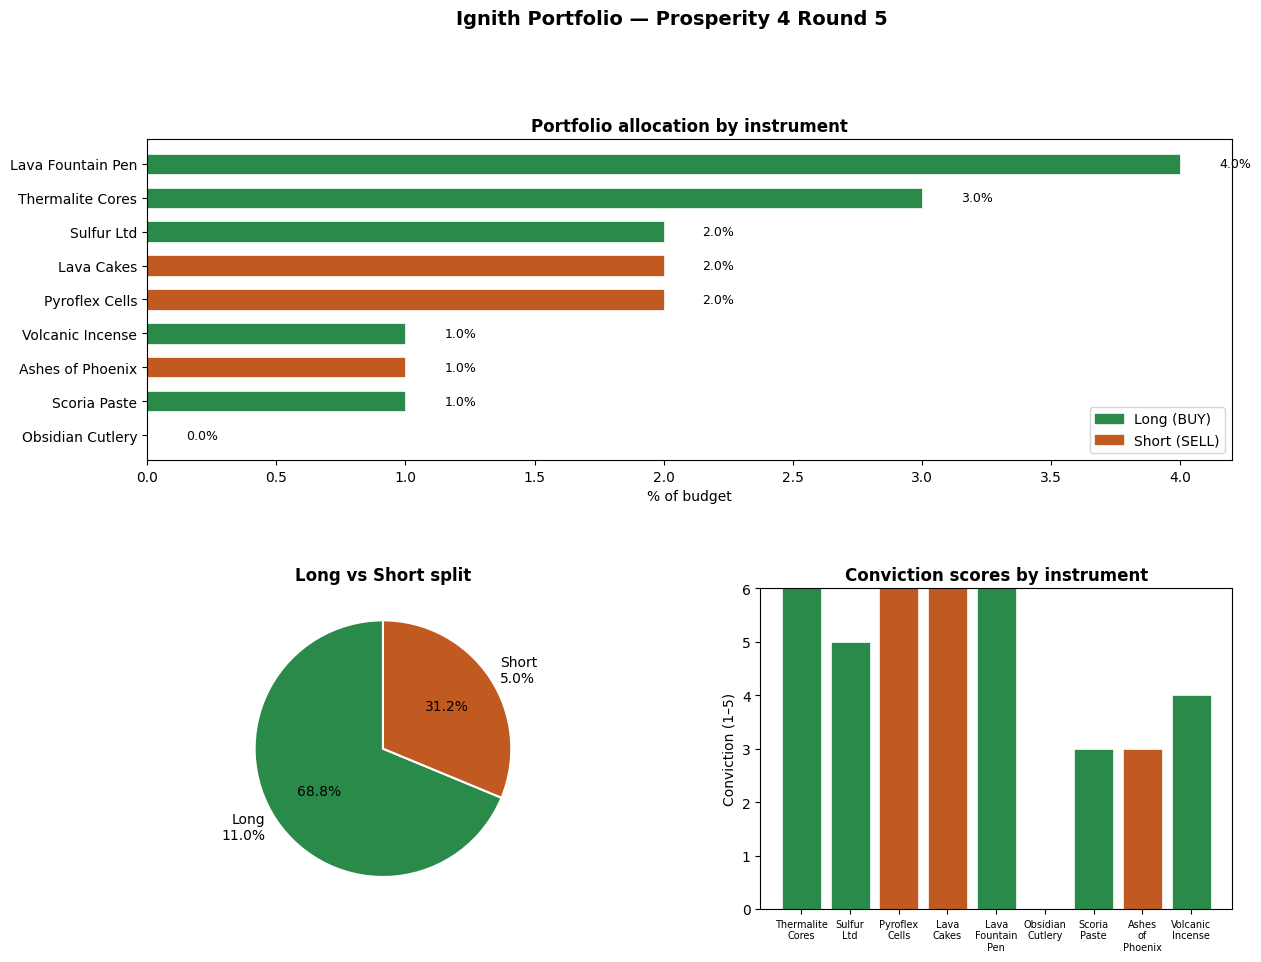

In [248]:
names  = list(allocations.keys())
pcts = [allocations[n] for n in names]
dirs   = [signals[n]["dir"] for n in names]
colors = ["#2a8a4a" if d > 0 else "#c05a20" for d in dirs]

idx      = np.argsort(pcts)[::-1]
names_s  = [names[i].replace("_", " ") for i in idx]
pcts_s   = [pcts[i] for i in idx]
colors_s = [colors[i] for i in idx]

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# --- Horizontal bar chart ---
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(names_s, pcts_s, color=colors_s, height=0.6, edgecolor='white', lw=0.5)
ax1.set_xlabel("% of budget")
ax1.set_title("Portfolio allocation by instrument", fontweight='bold')
ax1.invert_yaxis()
for bar, pct in zip(bars, pcts_s):
    ax1.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
             f"{pct:.1f}%", va='center', fontsize=9)
long_patch  = mpatches.Patch(color="#2a8a4a", label="Long (BUY)")
short_patch = mpatches.Patch(color="#c05a20", label="Short (SELL)")
ax1.legend(handles=[long_patch, short_patch], loc='lower right')

# --- Pie: long vs short split ---
ax2 = fig.add_subplot(gs[1, 0])
long_total  = sum(pcts[i] for i in range(len(names)) if dirs[i] > 0)
short_total = sum(pcts[i] for i in range(len(names)) if dirs[i] < 0)
ax2.pie([long_total, short_total],
        labels=[f"Long\n{long_total:.1f}%", f"Short\n{short_total:.1f}%"],
        colors=["#2a8a4a", "#c05a20"],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title("Long vs Short split", fontweight='bold')

# --- Conviction distribution ---
ax3 = fig.add_subplot(gs[1, 1])
conv_values = [signals[n]["conv"] for n in names]
bar_colors  = ["#2a8a4a" if signals[n]["dir"] > 0 else "#c05a20" for n in names]
ax3.bar([n.replace("_", "\n") for n in names], conv_values,
        color=bar_colors, edgecolor='white', lw=0.5)
ax3.set_ylabel("Conviction (1–5)")
ax3.set_title("Conviction scores by instrument", fontweight='bold')
ax3.tick_params(axis='x', labelsize=7)
ax3.set_ylim(0, 6)

plt.suptitle("Ignith Portfolio — Prosperity 4 Round 5", fontsize=14, fontweight='bold', y=1.01)
plt.savefig('ignith_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Final Submission Output

In [249]:
print("=" * 62)
print("  FINAL IGNITH PORTFOLIO — PROSPERITY 4 ROUND 5")
print("=" * 62)
print(f"{'Instrument':<25} {'Action':<5}  {'ER':<8}  {'XIRECs':>12}  {'Alloc%':>7}")
print("-" * 62)

total_deployed = 0
for name, pct in sorted(allocations.items(), key=lambda x: -signals[x[0]]["conv"]):
    s      = signals[name]
    action = "BUY " if s["dir"] > 0 else "SELL"
    xirecs = round(pct / 100 * BUDGET)
    er     = expected_return(s["conv"])
    total_deployed += xirecs
    print(f"{name.replace('_',' '):<25} {action:<5}  {er:<8.4f}  {xirecs:>12,}  {pct:>6.2f}%")

print("-" * 62)
print(f"{'TOTAL DEPLOYED':<25}        {total_deployed:>12,}  {total_deployed/BUDGET*100:>6.2f}%")
print(f"{'UNUSED (expires)':<25}        {BUDGET - total_deployed:>12,}")
print(f"{'TOTAL FEES':<25}        {sum(fee(p) for p in allocations.values()):>12,.0f}")
print("=" * 62)

assert total_deployed <= BUDGET, "ERROR: Over budget!"
print("\nAssertion passed: portfolio is within budget.")

  FINAL IGNITH PORTFOLIO — PROSPERITY 4 ROUND 5
Instrument                Action  ER              XIRECs   Alloc%
--------------------------------------------------------------
Lava Fountain Pen         BUY    0.0800          40,000    4.00%
Thermalite Cores          BUY    0.0640          30,000    3.00%
Lava Cakes                SELL   0.0560          20,000    2.00%
Pyroflex Cells            SELL   0.0480          20,000    2.00%
Sulfur Ltd                BUY    0.0400          20,000    2.00%
Volcanic Incense          BUY    0.0320          10,000    1.00%
Scoria Paste              BUY    0.0240          10,000    1.00%
Ashes of Phoenix          SELL   0.0240          10,000    1.00%
Obsidian Cutlery          SELL   0.0000               0    0.00%
--------------------------------------------------------------
TOTAL DEPLOYED                        160,000   16.00%
UNUSED (expires)                      840,000
TOTAL FEES                              4,000

Assertion passed: portfolio

### TODO:

Once we all agree on signals and intensity of the signal, find the optimal amount by estimating a more accurate expected return. After we find an interval we all agree on (how much we would expect each stock to rise/fall as a consequence of the news), rerun the optimizer.

In [250]:
# Calculate Total Gross Return and Total Fees
total_gross_return = 0
total_fees = 0

for name, p in allocations.items():
    s = signals[name]
    invested = (p / 100) * BUDGET
    exp_ret_decimal = expected_return(s['conv']) 
    
    # Calculate expected gross return and fee for this instrument
    instrument_return = invested * exp_ret_decimal
    instrument_fee = fee(p)
    
    total_gross_return += instrument_return
    total_fees += instrument_fee

total_net_return = total_gross_return - total_fees

print("-" * 50)
print(f"Total Expected Gross Return: {total_gross_return:,.0f} XIRECs")
print(f"Total Fees:                  {total_fees:,.0f} XIRECs")
print(f"Total Expected Net Return:   {total_net_return:,.0f} XIRECs")
print("-" * 50)


--------------------------------------------------
Total Expected Gross Return: 8,800 XIRECs
Total Fees:                  4,000 XIRECs
Total Expected Net Return:   4,800 XIRECs
--------------------------------------------------


In [251]:
signals = {
    "Thermalite_Cores":      {"dir": +1, "conv": 8},
    "Sulfur_Ltd":            {"dir": +1, "conv": 5},
    "Pyroflex_Cells":        {"dir": -1, "conv": 6},
    "Lava_Cakes":            {"dir": -1, "conv": 7},
    "Lava_Fountain_Pen":     {"dir": +1, "conv": 10},
    "Obsidian_Cutlery":      {"dir": -1, "conv": 0},
    "Scoria_Paste":          {"dir": +1, "conv": 3},
    "Ashes_of_Phoenix":      {"dir": -1, "conv": 3},
    "Volcanic_Incense":      {"dir": +1, "conv": 4},
}

def simulate_reality_check(expected_multiplier, actual_multiplier):
    budget = 1_000_000
    
    # --- 1. ALLOCATION PHASE (What you expected to happen) ---
    allocations = {}
    for name, s in signals.items():
        exp_ret = expected_multiplier * (np.exp(s["conv"] / 4) - 1)       # ---------------------------------
        optimal_r = exp_ret / 2
        # Original logic rounds down to the integer percentage
        allocations[name] = int(max(0, optimal_r * 100))
        
    # Check budget limit (if > 100%, scale down proportionally)
    total_alloc = sum(allocations.values())
    if total_alloc > 100:
        for name in allocations:
            allocations[name] = int((allocations[name] / total_alloc) * 100)
            
    # --- 2. REALITY PHASE (The actual market return) ---
    total_actual_gross = 0
    total_fees = 0
    
    print(f"=== EXPECTATION: {expected_multiplier} | REALITY: {actual_multiplier} ===")
    print(f"{'Instrument':<22} | {'Alloc%':>6} | {'Actual Ret':>10} | {'Invested':>10} | {'Fees':>8}")
    print("-" * 68)
    
    for name, p in sorted(allocations.items(), key=lambda x: -x[1]):
        s = signals[name]
        
        # ACTUAL RETURN uses the real multiplier (0.008)
        actual_ret_pct = actual_multiplier * (np.exp(s["conv"] / 4) - 1)  #--------------------------------------------
        
        invested = (p / 100) * budget
        instrument_fee = ((p / 100)**2) * budget
        
        # PnL is calculated on the actual return
        instrument_actual_return = invested * actual_ret_pct
        
        total_actual_gross += instrument_actual_return
        total_fees += instrument_fee
        
        if p > 0:
            print(f"{name:<22} | {p:>5}% | {actual_ret_pct*100:>9.1f}% | {invested:>10,.0f} | {instrument_fee:>8,.0f}")
        
    total_actual_net = total_actual_gross - total_fees
    
    print("-" * 68)
    print(f"Total Budget Deployed:          {sum(allocations.values())}%")
    print(f"Total ACTUAL Gross Return:       {total_actual_gross:,.0f} XIRECs")
    print(f"Total Fees Incurred (Fixed):     {total_fees:,.0f} XIRECs")
    
    if total_actual_net < 0:
        print(f"ACTUAL NET RETURN (LOSS):       {total_actual_net:,.0f} XIRECs ⚠️")
    else:
        print(f"ACTUAL NET RETURN (PROFIT):      {total_actual_net:,.0f} XIRECs")
    print("=" * 68 + "\n")


# Simulate your specific scenario!
simulate_reality_check(expected_multiplier=0.2, actual_multiplier=0.09)




=== EXPECTATION: 0.2 | REALITY: 0.09 ===
Instrument             | Alloc% | Actual Ret |   Invested |     Fees
--------------------------------------------------------------------
Lava_Fountain_Pen      |    34% |     100.6% |    340,000 |  115,600
Thermalite_Cores       |    19% |      57.5% |    190,000 |   36,100
Lava_Cakes             |    14% |      42.8% |    140,000 |   19,600
Pyroflex_Cells         |    10% |      31.3% |    100,000 |   10,000
Sulfur_Ltd             |     7% |      22.4% |     70,000 |    4,900
Volcanic_Incense       |     5% |      15.5% |     50,000 |    2,500
Scoria_Paste           |     3% |      10.1% |     30,000 |      900
Ashes_of_Phoenix       |     3% |      10.1% |     30,000 |      900
--------------------------------------------------------------------
Total Budget Deployed:          95%
Total ACTUAL Gross Return:       572,134 XIRECs
Total Fees Incurred (Fixed):     190,500 XIRECs
ACTUAL NET RETURN (PROFIT):      381,634 XIRECs



In [252]:
a= np.round((0.15 * (np.exp(8 / 4) - 1))*100 ,3)
print(" Extimated revenue asset Thermalite Cores",a,"%")

 Extimated revenue asset Thermalite Cores 95.836 %


In [253]:
e= np.round((0.15 * (np.exp(3 / 4) - 1))*100 ,3)
print(" Extimated less volatile ",e,"%")

 Extimated less volatile  16.755 %


In [254]:
b= np.round((0.09 * (np.exp(8 / 4) - 1))*100 ,3)
print(" Actual revenue asset Thermalite Cores",b,"%")

 Actual revenue asset Thermalite Cores 57.502 %


In [255]:
c= np.round((0.09 * (np.exp(3 / 4) - 1))*100 ,3)
print("Actuall less volatile asset ",c,"%")

Actuall less volatile asset  10.053 %


In [256]:
# Dizionario dei segnali
signals = {
    "Thermalite_Cores":      {"dir": +1, "conv": 8},
    "Sulfur_Ltd":            {"dir": +1, "conv": 5},
    "Pyroflex_Cells":        {"dir": -1, "conv": 6},
    "Lava_Cakes":            {"dir": -1, "conv": 7},
    "Lava_Fountain_Pen":     {"dir": +1, "conv": 10},
    "Obsidian_Cutlery":      {"dir": -1, "conv": 0},
    "Scoria_Paste":          {"dir": +1, "conv": 3},
    "Ashes_of_Phoenix":      {"dir": -1, "conv": 3},
    "Volcanic_Incense":      {"dir": +1, "conv": 4},
}

def simulate_direction_error(expected_multiplier, actual_multiplier, wrong_direction_assets=[]):
    budget = 1_000_000
    
    # --- 1. ALLOCAZIONE (Dimensionamento in base a ciò che ti aspetti) ---
    allocations = {}
    for name, s in signals.items():
        exp_ret = expected_multiplier * (np.exp(s["conv"] / 4) - 1)
        optimal_r = exp_ret / 2
        allocations[name] = int(max(0, optimal_r * 100))
        
    total_alloc = sum(allocations.values())
    if total_alloc > 100:
        for name in allocations:
            allocations[name] = int((allocations[name] / total_alloc) * 100)
            
    # --- 2. IL VERO PnL (Calcolato in base alla realtà e alle direzioni) ---
    total_actual_gross = 0
    total_fees = 0
    
    print(f"=== ASPETTATIVA (Multiplier): {expected_multiplier} | REALTÀ (Multiplier): {actual_multiplier} ===")
    if wrong_direction_assets:
        print(f"⚠️ ATTENZIONE: Hai sbagliato la direzione per: {', '.join(wrong_direction_assets)}")
    
    print(f"{'Instrument':<28} | {'Alloc%':>6} | {'Vero Ret':>9} | {'Invested':>10} | {'Fees':>8}")
    print("-" * 72)
    
    for name, p in sorted(allocations.items(), key=lambda x: -x[1]):
        s = signals[name]
        
        # Ritorno reale base
        actual_ret_pct = actual_multiplier * (np.exp(s["conv"] / 4) - 1)
        
        # SE HAI SBAGLIATO DIREZIONE, IL RITORNO DIVENTA NEGATIVO
        if name in wrong_direction_assets:
            actual_ret_pct = -actual_ret_pct
            
        invested = (p / 100) * budget
        instrument_fee = ((p / 100)**2) * budget
        
        # Incasso reale (Investimento * Vero Ritorno %)
        instrument_actual_return = invested * actual_ret_pct
        
        total_actual_gross += instrument_actual_return
        total_fees += instrument_fee
        
        if p > 0:
            # Mostra la X rossa se hai sbagliato
            display_name = name + " (WRONG) ❌" if name in wrong_direction_assets else name
            print(f"{display_name:<28} | {p:>5}% | {actual_ret_pct*100:>8.1f}% | {invested:>10,.0f} | {instrument_fee:>8,.0f}")
        
    total_actual_net = total_actual_gross - total_fees
    
    print("-" * 72)
    print(f"Totale Budget Utilizzato:      {sum(allocations.values())}%")
    print(f"VERO Ritorno Lordo Totale:      {total_actual_gross:,.0f} XIRECs")
    print(f"Commissioni Totali Pagate:      {total_fees:,.0f} XIRECs")
    
    if total_actual_net < 0:
        print(f"VERO RITORNO NETTO (PERDITA):  {total_actual_net:,.0f} XIRECs ⚠️")
    else:
        print(f"VERO RITORNO NETTO (PROFITTO):  {total_actual_net:,.0f} XIRECs")
    print("=" * 72 + "\n")


# ==============================================================
# PROVA QUESTI STRESS TEST
# ==============================================================

# 1. Nessun errore di direzione, ma calcolo sballato sul multiplier
simulate_direction_error(0.15, 0.09, wrong_direction_assets=[])

# 2. Errore di direzione sull'asset in cui avevi investito di più
simulate_direction_error(0.15, 0.09, wrong_direction_assets=["Sulfur_Ltd"])

# 3. Disastro totale: rendimento bassissimo E sbaglio su due asset principali
simulate_direction_error(0.15, 0.09, wrong_direction_assets=["Sulfur_Ltd", "Pyroflex_Cells"])


=== ASPETTATIVA (Multiplier): 0.15 | REALTÀ (Multiplier): 0.09 ===
Instrument                   | Alloc% |  Vero Ret |   Invested |     Fees
------------------------------------------------------------------------
Lava_Fountain_Pen            |    35% |    100.6% |    350,000 |  122,500
Thermalite_Cores             |    19% |     57.5% |    190,000 |   36,100
Lava_Cakes                   |    14% |     42.8% |    140,000 |   19,600
Pyroflex_Cells               |    10% |     31.3% |    100,000 |   10,000
Sulfur_Ltd                   |     7% |     22.4% |     70,000 |    4,900
Volcanic_Incense             |     5% |     15.5% |     50,000 |    2,500
Scoria_Paste                 |     3% |     10.1% |     30,000 |      900
Ashes_of_Phoenix             |     3% |     10.1% |     30,000 |      900
------------------------------------------------------------------------
Totale Budget Utilizzato:      96%
VERO Ritorno Lordo Totale:      582,198 XIRECs
Commissioni Totali Pagate:      197,400

In [257]:
# Dizionario dei segnali (LE TUE STIME)
signals = {
    "Thermalite_Cores":      {"dir": +1, "conv": 8},
    "Sulfur_Ltd":            {"dir": +1, "conv": 5},
    "Pyroflex_Cells":        {"dir": -1, "conv": 6},
    "Lava_Cakes":            {"dir": -1, "conv": 7},
    "Lava_Fountain_Pen":     {"dir": +1, "conv": 10},
    "Obsidian_Cutlery":      {"dir": -1, "conv": 0},
    "Scoria_Paste":          {"dir": +1, "conv": 3},
    "Ashes_of_Phoenix":      {"dir": -1, "conv": 3},
    "Volcanic_Incense":      {"dir": +1, "conv": 4},
}

def simulate_stress_test(expected_multiplier, actual_multiplier, wrong_direction_assets=[], actual_convictions={}):
    budget = 1_000_000
    
    # --- 1. ALLOCAZIONE (Dimensionamento in base alle tue stime) ---
    allocations = {}
    for name, s in signals.items():
        # Usa la formula esponenziale per l'allocazione
        exp_ret = expected_multiplier * (np.exp(s["conv"] / 4) - 1)
        optimal_r = exp_ret / 2
        allocations[name] = int(max(0, optimal_r * 100))
        
    total_alloc = sum(allocations.values())
    if total_alloc > 100:
        for name in allocations:
            allocations[name] = int((allocations[name] / total_alloc) * 100)
            
    # --- 2. IL VERO PnL (Calcolato in base alla dura realtà) ---
    total_actual_gross = 0
    total_fees = 0
    
    print(f"=== ASPETTATIVA (Multiplier): {expected_multiplier} | REALTÀ (Multiplier): {actual_multiplier} ===")
    if wrong_direction_assets:
        print(f"⚠️ DIREZIONE ERRATA per: {', '.join(wrong_direction_assets)}")
    if actual_convictions:
        print(f"⚠️ CONVICTION SOVRASTIMATA/ERRATA: {actual_convictions}")
    
    print(f"{'Instrument':<32} | {'Alloc%':>6} | {'Vero Ret':>9} | {'Invested':>10} | {'Fees':>8}")
    print("-" * 76)
    
    for name, p in sorted(allocations.items(), key=lambda x: -x[1]):
        s = signals[name]
        
        # PRENDE LA CONVICTION VERA: Se l'hai inserita in 'actual_convictions' usa quella,
        # altrimenti assume che la tua stima 's["conv"]' fosse corretta.
        real_conv = actual_convictions.get(name, s["conv"])
        
        # Ritorno reale calcolato con la formula esponenziale usando la VERA CONVICTION
        actual_ret_pct = actual_multiplier * (np.exp(real_conv / 4) - 1)
        
        # SE HAI SBAGLIATO DIREZIONE, IL RITORNO DIVENTA NEGATIVO
        if name in wrong_direction_assets:
            actual_ret_pct = -actual_ret_pct
            
        invested = (p / 100) * budget
        instrument_fee = ((p / 100)**2) * budget
        
        # Incasso reale (Investimento * Vero Ritorno %)
        instrument_actual_return = invested * actual_ret_pct
        
        total_actual_gross += instrument_actual_return
        total_fees += instrument_fee
        
        if p > 0:
            # Etichette di errore per farti capire a occhio dove hai sbagliato
            display_name = name
            if name in wrong_direction_assets:
                display_name += " ❌(DIR)"
            if name in actual_convictions:
                display_name += f" ⚠️(CV:{real_conv})"
                
            print(f"{display_name:<32} | {p:>5}% | {actual_ret_pct*100:>8.1f}% | {invested:>10,.0f} | {instrument_fee:>8,.0f}")
        
    total_actual_net = total_actual_gross - total_fees
    
    print("-" * 76)
    print(f"Totale Budget Utilizzato:      {sum(allocations.values())}%")
    print(f"VERO Ritorno Lordo Totale:      {total_actual_gross:,.0f} XIRECs")
    print(f"Commissioni Totali Pagate:      {total_fees:,.0f} XIRECs")
    
    if total_actual_net < 0:
        print(f"VERO RITORNO NETTO (PERDITA):  {total_actual_net:,.0f} XIRECs 🆘")
    else:
        print(f"VERO RITORNO NETTO (PROFITTO):  {total_actual_net:,.0f} XIRECs")
    print("=" * 76 + "\n")


# ==============================================================
# PROVA QUESTI STRESS TEST
# ==============================================================

# 1. Hai sbagliato pesantemente la Conviction di Lava Fountain Pen 
# (ti aspettavi 10, ma la realtà è stata solo 2)
simulate_stress_test(0.15, 0.15, actual_convictions={"Lava_Fountain_Pen": 10})

# 2. Hai sbagliato la direzione di Thermalite Cores E ANCHE la conviction di Sulfur Ltd
simulate_stress_test(0.15, 0.09, wrong_direction_assets=["Thermalite_Cores"], actual_convictions={"Lava_Fountain_Pen": 1})


=== ASPETTATIVA (Multiplier): 0.15 | REALTÀ (Multiplier): 0.15 ===
⚠️ CONVICTION SOVRASTIMATA/ERRATA: {'Lava_Fountain_Pen': 10}
Instrument                       | Alloc% |  Vero Ret |   Invested |     Fees
----------------------------------------------------------------------------
Lava_Fountain_Pen ⚠️(CV:10)      |    35% |    167.7% |    350,000 |  122,500
Thermalite_Cores                 |    19% |     95.8% |    190,000 |   36,100
Lava_Cakes                       |    14% |     71.3% |    140,000 |   19,600
Pyroflex_Cells                   |    10% |     52.2% |    100,000 |   10,000
Sulfur_Ltd                       |     7% |     37.4% |     70,000 |    4,900
Volcanic_Incense                 |     5% |     25.8% |     50,000 |    2,500
Scoria_Paste                     |     3% |     16.8% |     30,000 |      900
Ashes_of_Phoenix                 |     3% |     16.8% |     30,000 |      900
----------------------------------------------------------------------------
Totale Budget Ut